<a href="https://colab.research.google.com/github/anp2/Declarative-Pipeline/blob/master/EcommProj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

In [4]:
from google.colab import files

uploaded = files.upload()

Saving CustomersData.csv to CustomersData.csv
Saving Discount_Coupon.csv to Discount_Coupon.csv
Saving Marketing_Spend.csv to Marketing_Spend.csv
Saving Online_Sales.csv to Online_Sales.csv
Saving Tax_amount.xlsx to Tax_amount.xlsx


In [5]:
customer_df = pd.read_csv('CustomersData.csv')

disc_coupon_df = pd.read_csv('Discount_Coupon.csv')

sales_df = pd.read_csv('Online_Sales.csv')

marketing_df = pd.read_csv('Marketing_Spend.csv')

tax_df = pd.read_excel('Tax_amount.xlsx')

In [6]:
print("Customer Data")
display(customer_df.head())

print("Discount Coupon")
display(disc_coupon_df.head())

print("Online Sales")
display(sales_df.head())

print("Marketing Spend")
display(marketing_df.head())

print("Tax Data")
display(tax_df.head())

Customer Data


,CustomerID,Gender,Location,Tenure_Months
0,17850,M,Chicago,12
1,13047,M,California,43
2,12583,M,Chicago,33
3,13748,F,California,30
4,15100,M,California,49


Discount Coupon


,Month,Product_Category,Coupon_Code,Discount_pct
0,Jan,Apparel,SALE10,10
1,Feb,Apparel,SALE20,20
2,Mar,Apparel,SALE30,30
3,Jan,Nest-USA,ELEC10,10
4,Feb,Nest-USA,ELEC20,20


Online Sales


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status
0,17850,16679,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
1,17850,16680,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
2,17850,16681,1/1/2019,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used
3,17850,16682,1/1/2019,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used
4,17850,16682,1/1/2019,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used


Marketing Spend


,Date,Offline_Spend,Online_Spend
0,1/1/2019,4500,2424.50
1,1/2/2019,4500,3480.36
2,1/3/2019,4500,1576.38
3,1/4/2019,4500,2928.55
4,1/5/2019,4500,4055.30


Tax Data


,Product_Category,GST
0,Nest-USA,0.10
1,Office,0.10
2,Apparel,0.18
3,Bags,0.18
4,Drinkware,0.18


In [7]:
print("Customer Data:", customer_df.shape)

print("Doscount Coupon:", disc_coupon_df.shape)

print("Online Sales:", sales_df.shape)

print("Marketing Spend:", marketing_df.shape)

print("Tax Data:", tax_df.shape)

Customer Data: (1468, 4)
Doscount Coupon: (204, 4)
Online Sales: (52924, 10)
Marketing Spend: (365, 3)
Tax Data: (20, 2)


In [8]:
customer_df.info()

disc_coupon_df.info()

sales_df.info()

marketing_df.info()

tax_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1468 non-null   int64 
 1   Gender         1468 non-null   object
 2   Location       1468 non-null   object
 3   Tenure_Months  1468 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Month             204 non-null    object
 1   Product_Category  204 non-null    object
 2   Coupon_Code       204 non-null    object
 3   Discount_pct      204 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 6.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtyp

In [9]:
print(customer_df.dtypes)

CustomerID        int64
Gender           object
Location         object
Tenure_Months     int64
dtype: object


In [10]:
print(disc_coupon_df.dtypes)

Month               object
Product_Category    object
Coupon_Code         object
Discount_pct         int64
dtype: object


In [11]:
print(sales_df.dtypes)

CustomerID               int64
Transaction_ID           int64
Transaction_Date        object
Product_SKU             object
Product_Description     object
Product_Category        object
Quantity                 int64
Avg_Price              float64
Delivery_Charges       float64
Coupon_Status           object
dtype: object


In [12]:
print(marketing_df.dtypes)

Date              object
Offline_Spend      int64
Online_Spend     float64
dtype: object


In [13]:
print(tax_df.dtypes)

Product_Category     object
GST                 float64
dtype: object


In [14]:
sales_df['CustomerID'] = sales_df['CustomerID'].astype(str)


In [15]:
sales_df['Transaction_ID'] = sales_df['Transaction_ID'].astype(str)

In [16]:
sales_df['Product_SKU'] = sales_df['Product_SKU'].astype(str)

In [17]:
customer_df['CustomerID'] = customer_df['CustomerID'].astype(str)

In [18]:
print(sales_df.dtypes)

CustomerID              object
Transaction_ID          object
Transaction_Date        object
Product_SKU             object
Product_Description     object
Product_Category        object
Quantity                 int64
Avg_Price              float64
Delivery_Charges       float64
Coupon_Status           object
dtype: object


In [19]:
sales_df['Transaction_Date'] = pd.to_datetime(
    sales_df['Transaction_Date']
)

marketing_df['Date'] = pd.to_datetime(
    marketing_df['Date']
)

In [20]:
print(marketing_df.dtypes)

Date             datetime64[ns]
Offline_Spend             int64
Online_Spend            float64
dtype: object


In [21]:
for name, df in customer_df.items():

    print('=' * 60)

    print(name)

    print('=' * 60)

    print(df.isnull().sum())

    print('\n')

CustomerID
0


Gender
0


Location
0


Tenure_Months
0




In [22]:
for name, df in customer_df.items():

    print('=' * 60)

    print(name)

    print('=' * 60)

    missing_pct = (
        df.isnull().sum()
        / len(df)
    ) * 100

    print(
        missing_pct.round(2)
    )

    print('\n')

CustomerID
0.0


Gender
0.0


Location
0.0


Tenure_Months
0.0




In [23]:
sales_df.describe()

,Transaction_Date,Quantity,Avg_Price,Delivery_Charges
count,52924,52924.000000,52924.000000,52924.000000
mean,2019-07-05 19:16:09.450532864,4.497638,52.237646,10.517630
min,2019-01-01 00:00:00,1.000000,0.390000,0.000000
25%,2019-04-12 00:00:00,1.000000,5.700000,6.000000
50%,2019-07-13 00:00:00,1.000000,16.990000,6.000000
75%,2019-09-27 00:00:00,2.000000,102.130000,6.500000
max,2019-12-31 00:00:00,900.000000,355.740000,521.360000
std,NaN,20.104711,64.006882,19.475613


In [24]:
sales_df['Month'] = sales_df['Transaction_Date'].dt.month_name()

In [25]:
sales_df.describe()

,Transaction_Date,Quantity,Avg_Price,Delivery_Charges
count,52924,52924.000000,52924.000000,52924.000000
mean,2019-07-05 19:16:09.450532864,4.497638,52.237646,10.517630
min,2019-01-01 00:00:00,1.000000,0.390000,0.000000
25%,2019-04-12 00:00:00,1.000000,5.700000,6.000000
50%,2019-07-13 00:00:00,1.000000,16.990000,6.000000
75%,2019-09-27 00:00:00,2.000000,102.130000,6.500000
max,2019-12-31 00:00:00,900.000000,355.740000,521.360000
std,NaN,20.104711,64.006882,19.475613


In [26]:
marketing_df['Month'] = marketing_df['Date'].dt.month_name()

In [27]:
marketing_df.describe()

,Date,Offline_Spend,Online_Spend
count,365,365.000000,365.000000
mean,2019-07-02 00:00:00,2843.561644,1905.880740
min,2019-01-01 00:00:00,500.000000,320.250000
25%,2019-04-02 00:00:00,2500.000000,1258.600000
50%,2019-07-02 00:00:00,3000.000000,1881.940000
75%,2019-10-01 00:00:00,3500.000000,2435.120000
max,2019-12-31 00:00:00,5000.000000,4556.930000
std,NaN,952.292448,808.856853


In [28]:
merged_df = sales_df.merge(
    customer_df,
    on='CustomerID',
    how='left'
)

In [29]:
print(merged_df.shape)

merged_df.head()

(52924, 14)


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month,Gender,Location,Tenure_Months
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,January,M,Chicago,12
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,January,M,Chicago,12
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,January,M,Chicago,12
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,January,M,Chicago,12
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,January,M,Chicago,12


In [30]:
merged_df = merged_df.merge(
    tax_df,
    on='Product_Category',
    how='left'
)

In [31]:
print(merged_df.shape)

merged_df.head()

(52924, 15)


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month,Gender,Location,Tenure_Months,GST
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,January,M,Chicago,12,0.10
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,January,M,Chicago,12,0.10
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,January,M,Chicago,12,0.10
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,January,M,Chicago,12,0.18
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,January,M,Chicago,12,0.18


In [32]:
merged_df = merged_df.merge(
    disc_coupon_df,
    on=['Month', 'Product_Category'],
    how='left'
)

In [33]:
print(merged_df.shape)

merged_df.head()

(52924, 17)


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month,Gender,Location,Tenure_Months,GST,Coupon_Code,Discount_pct
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,January,M,Chicago,12,0.10,NaN,NaN
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,January,M,Chicago,12,0.10,NaN,NaN
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,January,M,Chicago,12,0.10,NaN,NaN
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,January,M,Chicago,12,0.18,NaN,NaN
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,January,M,Chicago,12,0.18,NaN,NaN


In [34]:
merged_df = merged_df.merge(
    marketing_df,
    left_on='Transaction_Date',
    right_on='Date',
    how='left'
)

In [35]:
print(merged_df.shape)

merged_df.head()

(52924, 21)


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Gender,Location,Tenure_Months,GST,Coupon_Code,Discount_pct,Date,Offline_Spend,Online_Spend,Month_y
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,M,Chicago,12,0.10,NaN,NaN,2019-01-01,4500,2424.5,January
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,M,Chicago,12,0.10,NaN,NaN,2019-01-01,4500,2424.5,January
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,...,M,Chicago,12,0.10,NaN,NaN,2019-01-01,4500,2424.5,January
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,...,M,Chicago,12,0.18,NaN,NaN,2019-01-01,4500,2424.5,January
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,...,M,Chicago,12,0.18,NaN,NaN,2019-01-01,4500,2424.5,January


In [36]:
merged_df.drop(
    columns='Date',
    inplace=True
)

In [37]:
print(merged_df.shape)

merged_df.head()

(52924, 20)


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month_x,Gender,Location,Tenure_Months,GST,Coupon_Code,Discount_pct,Offline_Spend,Online_Spend,Month_y
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,January,M,Chicago,12,0.10,NaN,NaN,4500,2424.5,January
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,January,M,Chicago,12,0.10,NaN,NaN,4500,2424.5,January
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,January,M,Chicago,12,0.10,NaN,NaN,4500,2424.5,January
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,January,M,Chicago,12,0.18,NaN,NaN,4500,2424.5,January
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,January,M,Chicago,12,0.18,NaN,NaN,4500,2424.5,January


In [38]:
merged_df.columns

Index(['CustomerID', 'Transaction_ID', 'Transaction_Date', 'Product_SKU',
       'Product_Description', 'Product_Category', 'Quantity', 'Avg_Price',
       'Delivery_Charges', 'Coupon_Status', 'Month_x', 'Gender', 'Location',
       'Tenure_Months', 'GST', 'Coupon_Code', 'Discount_pct', 'Offline_Spend',
       'Online_Spend', 'Month_y'],
      dtype='object')

In [39]:
merged_df.isnull().sum()

,0
CustomerID,0
Transaction_ID,0
Transaction_Date,0
Product_SKU,0
Product_Description,0
Product_Category,0
Quantity,0
Avg_Price,0
Delivery_Charges,0
Coupon_Status,0


In [40]:
(
    merged_df.isnull().sum()
    / len(merged_df)
) * 100

,0
CustomerID,0.000000
Transaction_ID,0.000000
Transaction_Date,0.000000
Product_SKU,0.000000
Product_Description,0.000000
Product_Category,0.000000
Quantity,0.000000
Avg_Price,0.000000
Delivery_Charges,0.000000
Coupon_Status,0.000000


In [41]:
merged_df['GST'] = (
    merged_df['GST']
    .fillna(0)
)

merged_df['Discount_pct'] = (
    merged_df['Discount_pct']
    .fillna(0)
)

In [42]:
merged_df['Offline_Spend'] = (
    merged_df['Offline_Spend']
    .fillna(0)
)

merged_df['Online_Spend'] = (
    merged_df['Online_Spend']
    .fillna(0)
)

In [43]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           52924 non-null  object        
 1   Transaction_ID       52924 non-null  object        
 2   Transaction_Date     52924 non-null  datetime64[ns]
 3   Product_SKU          52924 non-null  object        
 4   Product_Description  52924 non-null  object        
 5   Product_Category     52924 non-null  object        
 6   Quantity             52924 non-null  int64         
 7   Avg_Price            52924 non-null  float64       
 8   Delivery_Charges     52924 non-null  float64       
 9   Coupon_Status        52924 non-null  object        
 10  Month_x              52924 non-null  object        
 11  Gender               52924 non-null  object        
 12  Location             52924 non-null  object        
 13  Tenure_Months        52924 non-

In [44]:
required_columns = [
    'Quantity',
    'Avg_Price',
    'Discount_pct',
    'GST',
    'Delivery_Charges'
]

print(merged_df[required_columns].head())

   Quantity  Avg_Price  Discount_pct   GST  Delivery_Charges
0         1     153.71           0.0  0.10               6.5
1         1     153.71           0.0  0.10               6.5
2         1       2.05           0.0  0.10               6.5
3         5      17.53           0.0  0.18               6.5
4         1      16.50           0.0  0.18               6.5


In [45]:
numeric_cols = [
    'Quantity',
    'Avg_Price',
    'Discount_pct',
    'GST',
    'Delivery_Charges'
]

for col in numeric_cols:

    merged_df[col] = pd.to_numeric(
        merged_df[col],
        errors='coerce'
    )

In [46]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           52924 non-null  object        
 1   Transaction_ID       52924 non-null  object        
 2   Transaction_Date     52924 non-null  datetime64[ns]
 3   Product_SKU          52924 non-null  object        
 4   Product_Description  52924 non-null  object        
 5   Product_Category     52924 non-null  object        
 6   Quantity             52924 non-null  int64         
 7   Avg_Price            52924 non-null  float64       
 8   Delivery_Charges     52924 non-null  float64       
 9   Coupon_Status        52924 non-null  object        
 10  Month_x              52924 non-null  object        
 11  Gender               52924 non-null  object        
 12  Location             52924 non-null  object        
 13  Tenure_Months        52924 non-

In [47]:
merged_df[numeric_cols] = (
    merged_df[numeric_cols]
    .fillna(0)
)

In [48]:
merged_df[numeric_cols]

,Quantity,Avg_Price,Discount_pct,GST,Delivery_Charges
0,1,153.71,0.0,0.10,6.50
1,1,153.71,0.0,0.10,6.50
2,1,2.05,0.0,0.10,6.50
3,5,17.53,0.0,0.18,6.50
4,1,16.50,0.0,0.18,6.50
...,...,...,...,...,...
52919,1,121.30,0.0,0.10,6.50
52920,1,48.92,0.0,0.18,6.50
52921,1,151.88,0.0,0.10,6.50
52922,5,80.52,0.0,0.10,6.50


In [49]:
if merged_df['Discount_pct'].max() > 1:

    merged_df['Discount_pct'] = (
        merged_df['Discount_pct'] / 100
    )

In [50]:
 merged_df['Discount_pct']

,Discount_pct
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
52919,0.0
52920,0.0
52921,0.0
52922,0.0


In [51]:
if merged_df['GST'].max() > 1:

    merged_df['GST'] = (
        merged_df['GST'] / 100
    )

In [52]:
print(
    merged_df[
        ['Discount_pct','GST']
    ].head()
)

   Discount_pct   GST
0           0.0  0.10
1           0.0  0.10
2           0.0  0.10
3           0.0  0.18
4           0.0  0.18


In [53]:
merged_df['Base_Amount'] = (
    merged_df['Quantity']
    * merged_df['Avg_Price']
)

In [54]:
merged_df

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Gender,Location,Tenure_Months,GST,Coupon_Code,Discount_pct,Offline_Spend,Online_Spend,Month_y,Base_Amount
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,M,Chicago,12,0.10,NaN,0.0,4500,2424.50,January,153.71
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,M,Chicago,12,0.10,NaN,0.0,4500,2424.50,January,153.71
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.50,Used,...,M,Chicago,12,0.10,NaN,0.0,4500,2424.50,January,2.05
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.50,Not Used,...,M,Chicago,12,0.18,NaN,0.0,4500,2424.50,January,87.65
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.50,Used,...,M,Chicago,12,0.18,NaN,0.0,4500,2424.50,January,16.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,14410,48493,2019-12-31,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,121.30,6.50,Clicked,...,F,New York,45,0.10,NaN,0.0,4000,2058.75,December,121.30
52920,14410,48494,2019-12-31,GGOEGAEB091117,Google Zip Hoodie Black,Apparel,1,48.92,6.50,Used,...,F,New York,45,0.18,NaN,0.0,4000,2058.75,December,48.92
52921,14410,48495,2019-12-31,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1,151.88,6.50,Used,...,F,New York,45,0.10,NaN,0.0,4000,2058.75,December,151.88
52922,14600,48496,2019-12-31,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,6.50,Clicked,...,F,California,7,0.10,NaN,0.0,4000,2058.75,December,402.60


In [55]:
merged_df['Discounted_Amount'] = (
    merged_df['Base_Amount']
    * (1 - merged_df['Discount_pct'])
)

In [56]:
merged_df

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Location,Tenure_Months,GST,Coupon_Code,Discount_pct,Offline_Spend,Online_Spend,Month_y,Base_Amount,Discounted_Amount
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,Chicago,12,0.10,NaN,0.0,4500,2424.50,January,153.71,153.71
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,Chicago,12,0.10,NaN,0.0,4500,2424.50,January,153.71,153.71
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.50,Used,...,Chicago,12,0.10,NaN,0.0,4500,2424.50,January,2.05,2.05
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.50,Not Used,...,Chicago,12,0.18,NaN,0.0,4500,2424.50,January,87.65,87.65
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.50,Used,...,Chicago,12,0.18,NaN,0.0,4500,2424.50,January,16.50,16.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,14410,48493,2019-12-31,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,121.30,6.50,Clicked,...,New York,45,0.10,NaN,0.0,4000,2058.75,December,121.30,121.30
52920,14410,48494,2019-12-31,GGOEGAEB091117,Google Zip Hoodie Black,Apparel,1,48.92,6.50,Used,...,New York,45,0.18,NaN,0.0,4000,2058.75,December,48.92,48.92
52921,14410,48495,2019-12-31,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1,151.88,6.50,Used,...,New York,45,0.10,NaN,0.0,4000,2058.75,December,151.88,151.88
52922,14600,48496,2019-12-31,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,6.50,Clicked,...,California,7,0.10,NaN,0.0,4000,2058.75,December,402.60,402.60


In [57]:
merged_df['Taxed_Amount'] = (
    merged_df['Discounted_Amount']
    * (1 + merged_df['GST'])
)

In [58]:
merged_df

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Tenure_Months,GST,Coupon_Code,Discount_pct,Offline_Spend,Online_Spend,Month_y,Base_Amount,Discounted_Amount,Taxed_Amount
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,12,0.10,NaN,0.0,4500,2424.50,January,153.71,153.71,169.0810
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,12,0.10,NaN,0.0,4500,2424.50,January,153.71,153.71,169.0810
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.50,Used,...,12,0.10,NaN,0.0,4500,2424.50,January,2.05,2.05,2.2550
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.50,Not Used,...,12,0.18,NaN,0.0,4500,2424.50,January,87.65,87.65,103.4270
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.50,Used,...,12,0.18,NaN,0.0,4500,2424.50,January,16.50,16.50,19.4700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,14410,48493,2019-12-31,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,121.30,6.50,Clicked,...,45,0.10,NaN,0.0,4000,2058.75,December,121.30,121.30,133.4300
52920,14410,48494,2019-12-31,GGOEGAEB091117,Google Zip Hoodie Black,Apparel,1,48.92,6.50,Used,...,45,0.18,NaN,0.0,4000,2058.75,December,48.92,48.92,57.7256
52921,14410,48495,2019-12-31,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1,151.88,6.50,Used,...,45,0.10,NaN,0.0,4000,2058.75,December,151.88,151.88,167.0680
52922,14600,48496,2019-12-31,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,6.50,Clicked,...,7,0.10,NaN,0.0,4000,2058.75,December,402.60,402.60,442.8600


In [59]:
merged_df['Invoice_Value'] = (

    merged_df['Taxed_Amount']

    + merged_df['Delivery_Charges']

)

In [60]:
merged_df

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,GST,Coupon_Code,Discount_pct,Offline_Spend,Online_Spend,Month_y,Base_Amount,Discounted_Amount,Taxed_Amount,Invoice_Value
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,0.10,NaN,0.0,4500,2424.50,January,153.71,153.71,169.0810,175.5810
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,0.10,NaN,0.0,4500,2424.50,January,153.71,153.71,169.0810,175.5810
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.50,Used,...,0.10,NaN,0.0,4500,2424.50,January,2.05,2.05,2.2550,8.7550
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.50,Not Used,...,0.18,NaN,0.0,4500,2424.50,January,87.65,87.65,103.4270,109.9270
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.50,Used,...,0.18,NaN,0.0,4500,2424.50,January,16.50,16.50,19.4700,25.9700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,14410,48493,2019-12-31,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,121.30,6.50,Clicked,...,0.10,NaN,0.0,4000,2058.75,December,121.30,121.30,133.4300,139.9300
52920,14410,48494,2019-12-31,GGOEGAEB091117,Google Zip Hoodie Black,Apparel,1,48.92,6.50,Used,...,0.18,NaN,0.0,4000,2058.75,December,48.92,48.92,57.7256,64.2256
52921,14410,48495,2019-12-31,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1,151.88,6.50,Used,...,0.10,NaN,0.0,4000,2058.75,December,151.88,151.88,167.0680,173.5680
52922,14600,48496,2019-12-31,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,6.50,Clicked,...,0.10,NaN,0.0,4000,2058.75,December,402.60,402.60,442.8600,449.3600


In [61]:
merged_df[[
    'Quantity',
    'Avg_Price',
    'Discount_pct',
    'GST',
    'Delivery_Charges',
    'Invoice_Value'
]].head()

,Quantity,Avg_Price,Discount_pct,GST,Delivery_Charges,Invoice_Value
0,1,153.71,0.0,0.10,6.5,175.581
1,1,153.71,0.0,0.10,6.5,175.581
2,1,2.05,0.0,0.10,6.5,8.755
3,5,17.53,0.0,0.18,6.5,109.927
4,1,16.50,0.0,0.18,6.5,25.970


In [62]:
total_revenue = (
    merged_df['Invoice_Value']
    .sum()
)

print(
    f'Total Revenue: ₹{total_revenue:,.2f}'
)

Total Revenue: ₹5,673,745.82


In [63]:
total_orders = (
    merged_df['Transaction_ID']
    .nunique()
)

print(
    f'Total Orders: {total_orders}'
)

Total Orders: 25061


In [64]:
total_customers = (
    merged_df['CustomerID']
    .nunique()
)

print(
    f'Total Customers: {total_customers}'
)

Total Customers: 1468


In [65]:
aov = (
    total_revenue
    / total_orders
)

print(
    f'Average Order Value: ₹{aov:,.2f}'
)

Average Order Value: ₹226.40


In [66]:
merged_df[['Invoice_Value']].describe()

,Invoice_Value
count,52924.000000
mean,107.205537
std,181.734258
min,4.861600
25%,21.094560
50%,47.288200
75%,141.547000
max,11044.009500


In [67]:
# 1. Identify the months with the highest and lowest customer acquisition count.
# What strategies could be implemented to address the fluctuations and ensure consistent growth throughout the year?

In [68]:
# Find each customer's first purchase date
customer_acquisition = (
    sales_df
    .groupby('CustomerID')['Transaction_Date']
    .min()
    .reset_index()
)

customer_acquisition.rename(
    columns={
        'Transaction_Date':'First_Purchase_Date'
    },
    inplace=True
)

customer_acquisition.head()

,CustomerID,First_Purchase_Date
0,12346,2019-09-15
1,12347,2019-03-24
2,12348,2019-06-22
3,12350,2019-12-14
4,12356,2019-09-15


In [69]:
# Extract Month
customer_acquisition['Acquisition_Month'] = (
    customer_acquisition['First_Purchase_Date']
    .dt.month_name()
)

In [70]:
customer_acquisition.head()

,CustomerID,First_Purchase_Date,Acquisition_Month
0,12346,2019-09-15,September
1,12347,2019-03-24,March
2,12348,2019-06-22,June
3,12350,2019-12-14,December
4,12356,2019-09-15,September


In [71]:
# Count Customer Acquisitions by Month
monthly_acquisition = (
    customer_acquisition
    .groupby('Acquisition_Month')
    .size()
    .reset_index(name='Customer_Count')
)

In [72]:
customer_acquisition.head()

,CustomerID,First_Purchase_Date,Acquisition_Month
0,12346,2019-09-15,September
1,12347,2019-03-24,March
2,12348,2019-06-22,June
3,12350,2019-12-14,December
4,12356,2019-09-15,September


In [73]:
# Sort Months Chronologically
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

monthly_acquisition['Acquisition_Month'] = pd.Categorical(
    monthly_acquisition['Acquisition_Month'],
    categories=month_order,
    ordered=True
)

monthly_acquisition = (
    monthly_acquisition
    .sort_values('Acquisition_Month')
)

monthly_acquisition

,Acquisition_Month,Customer_Count
4,January,215
3,February,96
7,March,177
0,April,163
8,May,112
6,June,137
5,July,94
1,August,135
11,September,78
10,October,87


In [74]:
# Identify Highest and Lowest Acquisition Months
highest_month = monthly_acquisition.loc[
    monthly_acquisition['Customer_Count'].idxmax()
]

lowest_month = monthly_acquisition.loc[
    monthly_acquisition['Customer_Count'].idxmin()
]

print(
    f"Highest Acquisition Month: "
    f"{highest_month['Acquisition_Month']} "
    f"({highest_month['Customer_Count']} customers)"
)

print(
    f"Lowest Acquisition Month: "
    f"{lowest_month['Acquisition_Month']} "
    f"({lowest_month['Customer_Count']} customers)"
)

Highest Acquisition Month: January (215 customers)
Lowest Acquisition Month: November (68 customers)


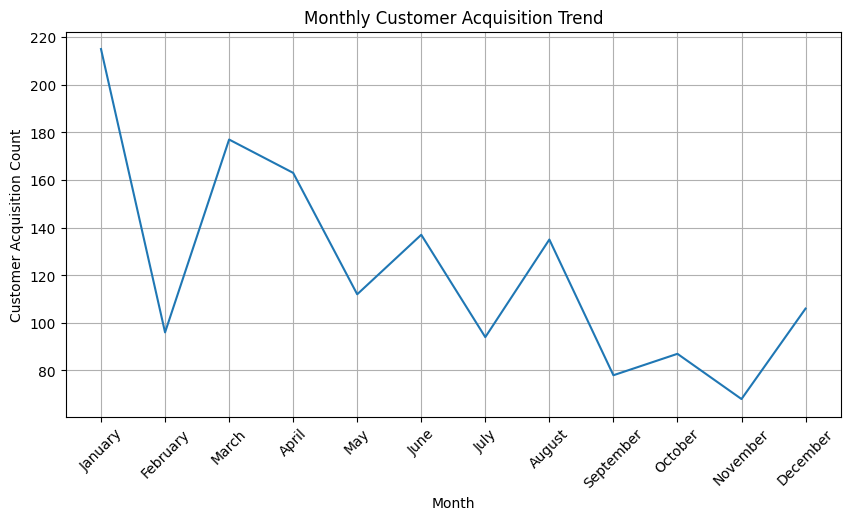

In [75]:
# Visualize the Trend
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_acquisition['Acquisition_Month'],
    monthly_acquisition['Customer_Count']
)

plt.xticks(rotation=45)

plt.xlabel('Month')

plt.ylabel('Customer Acquisition Count')

plt.title('Monthly Customer Acquisition Trend')

plt.grid(True)

plt.show()

In [76]:
# Customer acquisition was defined as a customer's first purchase.
# The earliest transaction date for each customer was identified and grouped by month to calculate monthly acquisition counts.
# The months with the highest and lowest acquisition were then determined.
# To reduce fluctuations and ensure steady growth, strategies such as increasing marketing efforts during low-performing months,
# offering promotions, implementing referral programs, and replicating successful campaigns from high-performing months are recommended.

# 2. Analyze Monthly Customer Acquisition Trends

In [78]:
monthly_acquisition

,Acquisition_Month,Customer_Count
4,January,215
3,February,96
7,March,177
0,April,163
8,May,112
6,June,137
5,July,94
1,August,135
11,September,78
10,October,87


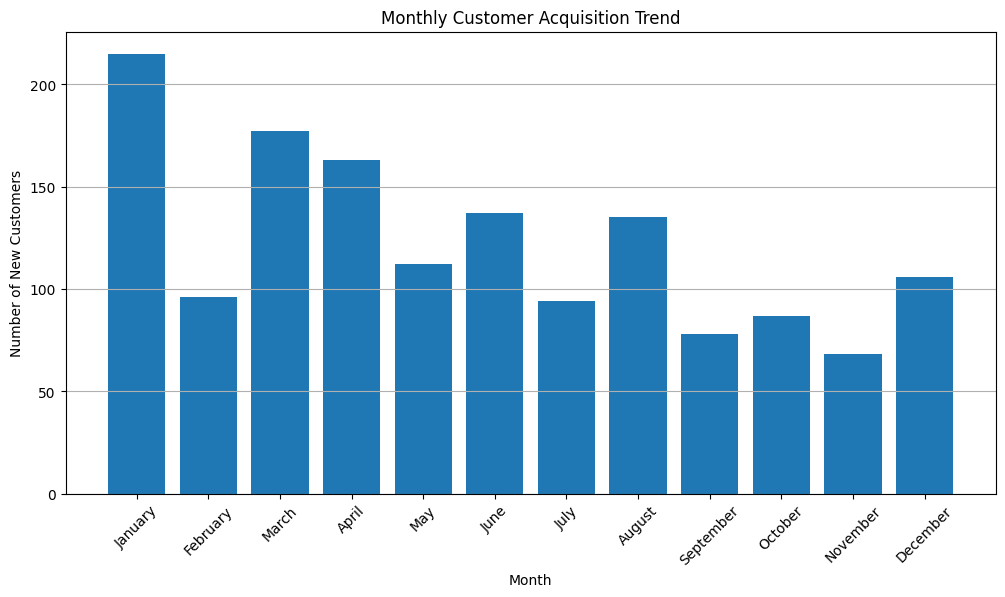

In [80]:
# Visualize Monthly Acquisition Trends
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    monthly_acquisition['Acquisition_Month'],
    monthly_acquisition['Customer_Count']
)

plt.xticks(rotation=45)

plt.xlabel('Month')

plt.ylabel('Number of New Customers')

plt.title('Monthly Customer Acquisition Trend')

plt.grid(axis='y')

plt.show()

In [81]:
# Calculate Average Monthly Acquisition

average_acquisition = (
    monthly_acquisition['Customer_Count']
    .mean()
)

print(
    f'Average Monthly Acquisition: '
    f'{average_acquisition:.0f}'
)

Average Monthly Acquisition: 122


In [82]:
# Categorize Months
# Identify months that perform above and below average.
monthly_acquisition['Performance'] = (
    monthly_acquisition['Customer_Count']
    .apply(
        lambda x:
        'High'
        if x >= average_acquisition
        else 'Low'
    )
)

monthly_acquisition

,Acquisition_Month,Customer_Count,Performance
4,January,215,High
3,February,96,Low
7,March,177,High
0,April,163,High
8,May,112,Low
6,June,137,High
5,July,94,Low
1,August,135,High
11,September,78,Low
10,October,87,Low


In [83]:
# Identify High and Low Performing Months
high_months = monthly_acquisition[
    monthly_acquisition['Performance']
    == 'High'
]

low_months = monthly_acquisition[
    monthly_acquisition['Performance']
    == 'Low'
]

print('High Performing Months')

display(high_months)

print('Low Performing Months')

display(low_months)

High Performing Months


,Acquisition_Month,Customer_Count,Performance
4,January,215,High
7,March,177,High
0,April,163,High
6,June,137,High
1,August,135,High


Low Performing Months


,Acquisition_Month,Customer_Count,Performance
3,February,96,Low
8,May,112,Low
5,July,94,Low
11,September,78,Low
10,October,87,Low
9,November,68,Low
2,December,106,Low


3. Identify periods with the strongest and weakest retention **rates** **bold text**

In [84]:
# Create Year-Month Column

sales_df['Year_Month'] = (
    sales_df['Transaction_Date']
    .dt.to_period('M')
)

In [86]:
sales_df['Year_Month']

,Year_Month
0,2019-01
1,2019-01
2,2019-01
3,2019-01
4,2019-01
...,...
52919,2019-12
52920,2019-12
52921,2019-12
52922,2019-12


In [87]:
# Create Monthly Customer Lists
# Group customers for each month.
monthly_customers = (
    sales_df
    .groupby('Year_Month')['CustomerID']
    .apply(set)
    .sort_index()
)

monthly_customers.head()

,CustomerID
Year_Month,
2019-01,"{13448, 14849, 14911, 16995, 15311, 15165, 179..."
2019-02,"{14911, 17402, 15311, 12395, 15373, 16327, 125..."
2019-03,"{14911, 14404, 16221, 15304, 14085, 17812, 159..."
2019-04,"{14911, 15358, 17262, 18071, 13984, 15311, 178..."
2019-05,"{13448, 15311, 14085, 17975, 14062, 13225, 173..."


In [89]:
# Calculate Monthly Retention Rates

retention_data = []

months = monthly_customers.index.tolist()

for i in range(len(months)-1):

    current_month = months[i]

    next_month = months[i+1]

    current_customers = monthly_customers[current_month]

    next_customers = monthly_customers[next_month]

    retained_customers = (
        current_customers
        .intersection(next_customers)
    )

    retention_rate = (
        len(retained_customers)
        / len(current_customers)
    ) * 100

    retention_data.append({

        'Month': str(current_month),

        'Next_Month': str(next_month),

        'Customers_Current_Month': len(current_customers),

        'Retained_Customers': len(retained_customers),

        'Retention_Rate': round(
            retention_rate,
            2
        )
    })

In [93]:
retention_data[1]

{'Month': '2019-02',
 'Next_Month': '2019-03',
 'Customers_Current_Month': 109,
 'Retained_Customers': 11,
 'Retention_Rate': 10.09}

In [94]:
# Create Retention DataFrame
retention_df = pd.DataFrame(
    retention_data
)

retention_df

,Month,Next_Month,Customers_Current_Month,Retained_Customers,Retention_Rate
0,2019-01,2019-02,215,13,6.05
1,2019-02,2019-03,109,11,10.09
2,2019-03,2019-04,208,24,11.54
3,2019-04,2019-05,224,25,11.16
4,2019-05,2019-06,200,37,18.50
5,2019-06,2019-07,259,58,22.39
6,2019-07,2019-08,236,65,27.54
7,2019-08,2019-09,300,44,14.67
8,2019-09,2019-10,193,29,15.03
9,2019-10,2019-11,210,31,14.76


In [95]:
# Identify Strongest and Weakest Months

strongest = retention_df.loc[
    retention_df['Retention_Rate']
    .idxmax()
]

weakest = retention_df.loc[
    retention_df['Retention_Rate']
    .idxmin()
]

print(
    f"Strongest Retention: "
    f"{strongest['Month']} "
    f"({strongest['Retention_Rate']}%)"
)

print(
    f"Weakest Retention: "
    f"{weakest['Month']} "
    f"({weakest['Retention_Rate']}%)"
)

Strongest Retention: 2019-07 (27.54%)
Weakest Retention: 2019-01 (6.05%)


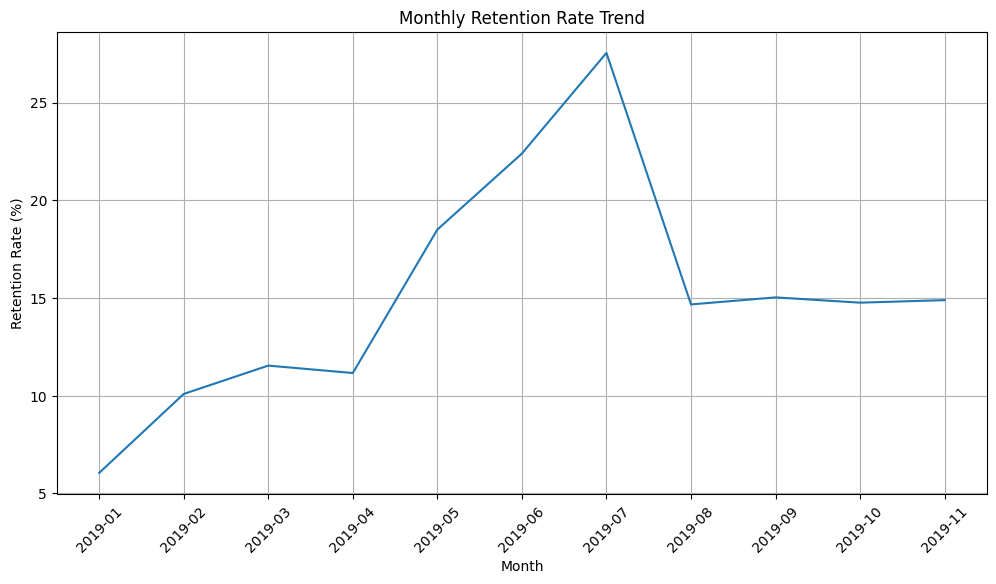

In [96]:
# Visualize Retention Trend
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    retention_df['Month'],
    retention_df['Retention_Rate']
)

plt.xticks(rotation=45)

plt.xlabel('Month')

plt.ylabel('Retention Rate (%)')

plt.title('Monthly Retention Rate Trend')

plt.grid(True)

plt.show()

**4. Analyze customer behavior during high-retention months**

In [97]:
# Identify High-Retention Months

top_retention_months = (
    retention_df
    .sort_values(
        by='Retention_Rate',
        ascending=False
    )
    .head(3)
)

top_retention_months

,Month,Next_Month,Customers_Current_Month,Retained_Customers,Retention_Rate
6,2019-07,2019-08,236,65,27.54
5,2019-06,2019-07,259,58,22.39
4,2019-05,2019-06,200,37,18.50


In [98]:
# Extract those months.

high_retention_months = (
    top_retention_months['Month']
    .tolist()
)

high_retention_months

['2019-07', '2019-06', '2019-05']

In [110]:
# Filter Transactions
# Create Year_Month.

merged_df['Year_Month'] = (
    merged_df['Transaction_Date']
    .dt.to_period('M')
    .astype(str)
)

high_retention_sales = merged_df[
    merged_df['Year_Month']
    .isin(high_retention_months)
]


In [111]:
# Analyze Product Categories

category_analysis = (
    high_retention_sales
    .groupby('Product_Category')
    ['Quantity']
    .sum()
    .sort_values(
        ascending=False
    )
)

category_analysis

,Quantity
Product_Category,
Office,22728
Apparel,9687
Drinkware,8164
Lifestyle,7171
Nest-USA,4882
Bags,3858
Notebooks & Journals,3194
Housewares,1222
Bottles,775


In [112]:
# Analyze Coupon Usage

coupon_analysis = (
    high_retention_sales
    ['Coupon_Status']
    .value_counts()
)

coupon_analysis

,count
Coupon_Status,
Clicked,7187
Used,4668
Not Used,2161


In [113]:
# Calculate percentages.

coupon_percentage = (

    high_retention_sales['Coupon_Status'].value_counts(normalize=True) * 100

).round(2)

coupon_percentage

,proportion
Coupon_Status,
Clicked,51.28
Used,33.30
Not Used,15.42


In [114]:
# Analyze Invoice Value
# If Invoice_Value already exists:

invoice_analysis = (
    high_retention_sales['Invoice_Value'].describe()
)

invoice_analysis

,Invoice_Value
count,14016.000000
mean,84.250018
std,142.725648
min,6.695200
25%,18.828960
50%,31.950400
75%,117.710000
max,4727.850000


In [115]:
# Analyze Purchase Frequency

purchase_frequency = (

    high_retention_sales

    .groupby('CustomerID')

    ['Transaction_ID']

    .nunique()

)

purchase_frequency.describe()

,Transaction_ID
count,573.000000
mean,11.373473
std,12.759069
min,1.000000
25%,3.000000
50%,7.000000
75%,15.000000
max,93.000000


In [116]:
# Analyze Top Products

top_products = (

    high_retention_sales

    .groupby('Product_Description')

    ['Quantity']

    .sum()

    .sort_values(
        ascending=False
    )

    .head(10)

)

top_products

,Quantity
Product_Description,
Google 22 oz Water Bottle,4420
Maze Pen,4044
Google Sunglasses,3643
Recycled Paper Journal Set,2406
Sport Bag,1912
Google Kick Ball,1884
Foam Can and Bottle Cooler,1456
Google Metallic Notebook Set,1303
Nest Cam Outdoor Security Camera - USA,1283


In [117]:
# Create a Summary Table

summary = {

    'Average Invoice Value':

        high_retention_sales[
            'Invoice_Value'
        ].mean(),

    'Average Quantity Purchased':

        high_retention_sales[
            'Quantity'
        ].mean(),

    'Unique Customers':

        high_retention_sales[
            'CustomerID'
        ].nunique(),

    'Total Transactions':

        high_retention_sales[
            'Transaction_ID'
        ].nunique()

}

summary

{'Average Invoice Value': np.float64(84.25001807648401),
 'Average Quantity Purchased': np.float64(4.511415525114155),
 'Unique Customers': 573,
 'Total Transactions': 6054}